In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import re

In [3]:
request_header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"
}

In [4]:
title = []
current_price = []
rating = []
reviews_ratings = []
brand = []
capacity = []
auto_type = []
load_type = []
original_price = []
discount = []
warranty_on_product = []
rpm = []

In [6]:
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8"
}

url = "https://www.flipkart.com/search?q=washing+machine"

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.text[:200])

403
<!DOCTYPE html><html lang=en><meta charset=UTF-8><meta content="width=device-width,initial-scale=1"name=viewport><title>Flipkart reCAPTCHA</title><link href=https://static-assets-web.flixcart.com/batm


In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nikit\OneDrive\Documents\Flipkart_project\washing_machine.csv")

df.head()

,Unnamed: 0,DateTime,temperature,power,energy,aX,aY,aZ,gX,gY,gZ
0,0,2021-05-11 19:20:28.626264,31.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2021-05-11 19:20:28.637266,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2021-05-11 19:20:28.655293,NaN,NaN,41731.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2021-05-11 19:20:28.906953,NaN,NaN,NaN,0.1,NaN,NaN,NaN,NaN,NaN
4,4,2021-05-11 19:20:28.928968,NaN,NaN,NaN,NaN,-0.0,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70454 entries, 0 to 70453
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70454 non-null  int64  
 1   DateTime     70454 non-null  str    
 2   temperature  30 non-null     float64
 3   power        1910 non-null   float64
 4   energy       1907 non-null   float64
 5   aX           11102 non-null  float64
 6   aY           11101 non-null  float64
 7   aZ           11101 non-null  float64
 8   gX           11101 non-null  float64
 9   gY           11101 non-null  float64
 10  gZ           11101 non-null  float64
dtypes: float64(9), int64(1), str(1)
memory usage: 7.7 MB


In [10]:
df.shape


(70454, 11)

In [11]:
df.columns

Index(['Unnamed: 0', 'DateTime', 'temperature', 'power', 'energy', 'aX', 'aY',
       'aZ', 'gX', 'gY', 'gZ'],
      dtype='str')

In [12]:
df = df.drop(columns=["Unnamed: 0"])

df.isnull().sum()

DateTime           0
temperature    70424
power          68544
energy         68547
aX             59352
aY             59353
aZ             59353
gX             59353
gY             59353
gZ             59353
dtype: int64

In [13]:
df.describe()



,temperature,power,energy,aX,aY,aZ,gX,gY,gZ
count,30.000000,1910.000000,1907.000000,11102.000000,11101.000000,11101.000000,11101.000000,11101.000000,11101.000000
mean,34.065333,265.828775,44821.116413,0.082228,-0.001468,1.083488,0.161130,-0.058968,0.034519
std,6.093814,579.492445,17633.753519,0.124368,0.101256,0.197649,4.269637,2.615913,0.280747
min,30.770000,0.000000,0.000000,-0.900000,-0.800000,-0.600000,-45.000000,-69.500000,-2.600000
25%,32.100000,12.955000,49878.000000,0.000000,0.000000,1.100000,-0.100000,-0.200000,0.000000
50%,32.315000,86.005000,52068.000000,0.100000,0.000000,1.100000,0.200000,0.000000,0.000000
75%,32.860000,196.500000,53784.000000,0.100000,0.000000,1.100000,0.600000,0.200000,0.100000
max,57.650000,2337.550000,56846.000000,1.000000,0.900000,2.000000,36.200000,67.000000,3.500000


In [15]:
df.isnull().sum()

DateTime           0
temperature    70424
power          68544
energy         68547
aX             59352
aY             59353
aZ             59353
gX             59353
gY             59353
gZ             59353
dtype: int64

In [16]:
df.describe()

,temperature,power,energy,aX,aY,aZ,gX,gY,gZ
count,30.000000,1910.000000,1907.000000,11102.000000,11101.000000,11101.000000,11101.000000,11101.000000,11101.000000
mean,34.065333,265.828775,44821.116413,0.082228,-0.001468,1.083488,0.161130,-0.058968,0.034519
std,6.093814,579.492445,17633.753519,0.124368,0.101256,0.197649,4.269637,2.615913,0.280747
min,30.770000,0.000000,0.000000,-0.900000,-0.800000,-0.600000,-45.000000,-69.500000,-2.600000
25%,32.100000,12.955000,49878.000000,0.000000,0.000000,1.100000,-0.100000,-0.200000,0.000000
50%,32.315000,86.005000,52068.000000,0.100000,0.000000,1.100000,0.200000,0.000000,0.000000
75%,32.860000,196.500000,53784.000000,0.100000,0.000000,1.100000,0.600000,0.200000,0.100000
max,57.650000,2337.550000,56846.000000,1.000000,0.900000,2.000000,36.200000,67.000000,3.500000


In [17]:
df = df.fillna(0)

df.isnull().sum()


DateTime       0
temperature    0
power          0
energy         0
aX             0
aY             0
aZ             0
gX             0
gY             0
gZ             0
dtype: int64

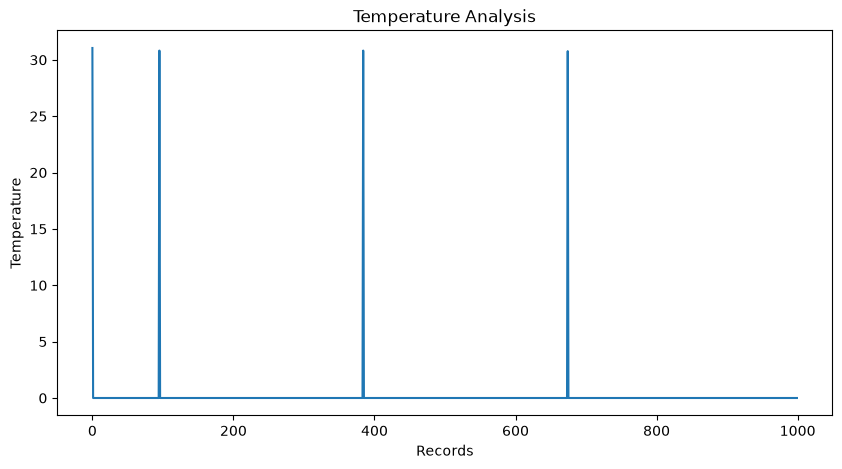

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["temperature"][:1000])
plt.title("Temperature Analysis")
plt.xlabel("Records")
plt.ylabel("Temperature")
plt.show()

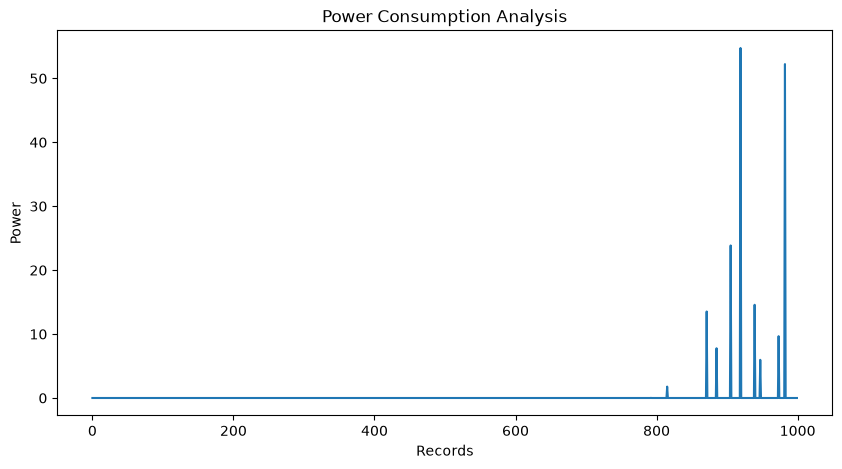

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df["power"][:1000])
plt.title("Power Consumption Analysis")
plt.xlabel("Records")
plt.ylabel("Power")
plt.show()

In [20]:
print("Maximum Energy:", df["energy"].max())
print("Minimum Energy:", df["energy"].min())
print("Average Energy:", df["energy"].mean())

Maximum Energy: 56846.0
Minimum Energy: 0.0
Average Energy: 1213.186887898487


In [21]:
df.corr(numeric_only=True)

,temperature,power,energy,aX,aY,aZ,gX,gY,gZ
temperature,1.000000,-0.001399,-0.003149,-0.004561,0.000117,-0.008622,-0.000304,0.000182,-0.000986
power,-0.001399,1.000000,-0.010664,-0.015444,0.000396,-0.029196,-0.001030,0.000616,-0.003338
energy,-0.003149,-0.010664,1.000000,-0.034764,0.000892,-0.065718,-0.002320,0.001386,-0.007514
aX,-0.004561,-0.015444,-0.034764,1.000000,0.001292,-0.095179,-0.003359,0.002007,-0.010883
aY,0.000117,0.000396,0.000892,0.001292,1.000000,0.002442,0.000086,-0.000051,0.000279
aZ,-0.008622,-0.029196,-0.065718,-0.095179,0.002442,1.000000,-0.006351,0.003795,-0.020573
gX,-0.000304,-0.001030,-0.002320,-0.003359,0.000086,-0.006351,1.000000,0.000134,-0.000726
gY,0.000182,0.000616,0.001386,0.002007,-0.000051,0.003795,0.000134,1.000000,0.000434
gZ,-0.000986,-0.003338,-0.007514,-0.010883,0.000279,-0.020573,-0.000726,0.000434,1.000000


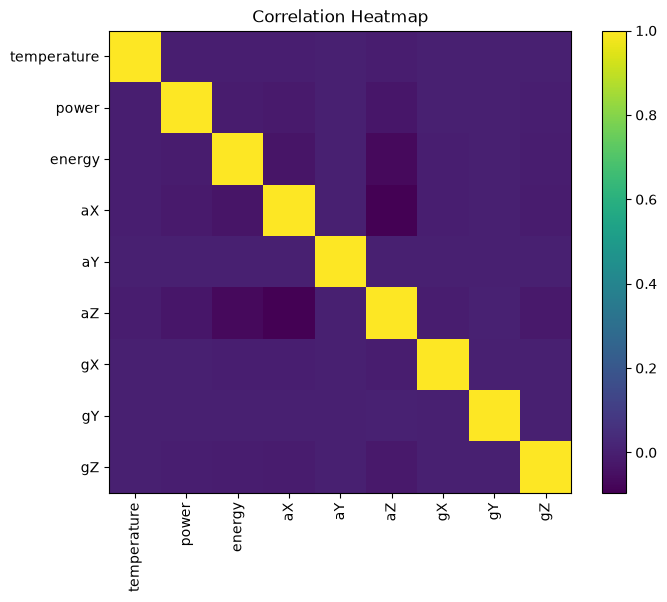

In [22]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


In [23]:
print("Total Records:", len(df))
print("Average Temperature:", df["temperature"].mean())
print("Maximum Power:", df["power"].max())
print("Total Energy:", df["energy"].sum())

Total Records: 70454
Average Temperature: 0.014505351009169104
Maximum Power: 2337.55
Total Energy: 85473869.0
